In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')
import seaborn as sns
import matplotlib.pyplot as plt

/kaggle/input/datasets/mojtaba142/hotel-booking/hotel_booking.csv


In [2]:
df = pd.read_csv('/kaggle/input/datasets/mojtaba142/hotel-booking/hotel_booking.csv')

# Data Inspection

In [3]:
# General inspection of the dataset
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Ernest Barnes,Ernest.Barnes31@outlook.com,669-792-1661,************4322
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,Transient,0.0,0,0,Check-Out,2015-07-01,Andrea Baker,Andrea_Baker94@aol.com,858-637-6955,************9157
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Rebecca Parker,Rebecca_Parker@comcast.net,652-885-2745,************3734
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,Transient,75.0,0,0,Check-Out,2015-07-02,Laura Murray,Laura_M@gmail.com,364-656-8427,************5677
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,Transient,98.0,0,1,Check-Out,2015-07-03,Linda Hines,LHines@verizon.com,713-226-5883,************5498


In [4]:
# Statistic Metrics of the dataset
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [5]:
# Checking the shape of the dataset
print(f'Rows:{df.shape[0]} -- Columns: {df.shape[1]}')

Rows:119390 -- Columns: 36


In [6]:
# Check missing values
df.isna().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [7]:
# Check for duplicates
df.duplicated().sum()

df[df.duplicated()]

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date,name,email,phone-number,credit_card


**Note:** The dataset used in this project is an extended version of the original Hotel Booking Demand dataset. Additional synthetic customer-identification fields (name, email, phone number, credit card) eliminate the duplicate records commonly reported in the original dataset.

# Explorative Data Analysis

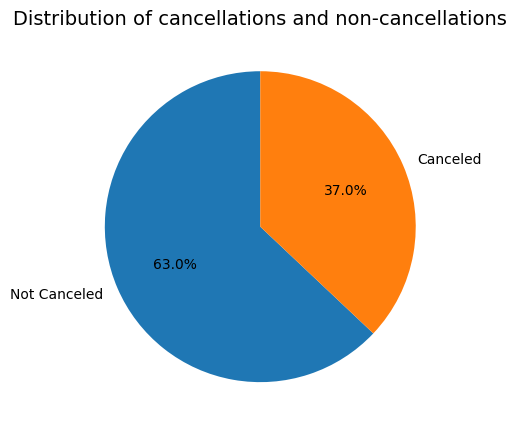

In [8]:
# Question: What is the breakdown of cancellations and non-cancellations
# Visualize the distribution of cancellation and non-cancellation
cancellation_counts = df['is_canceled'].value_counts()
plt.figure(figsize=(5,5))
plt.pie(cancellation_counts, labels=['Not Canceled', 'Canceled'], autopct='%1.1f%%', startangle=90)

plt.title('Distribution of cancellations and non-cancellations', fontsize=14)
plt.tight_layout()
plt.show()

### Analysis: Breakdown of Cancellations
The chart reveals that while **63.0%** of the bookings are successfully completed (not canceled), a substantial **37.0%** of all bookings end up being canceled. 

In the hospitality industry, a cancellation rate this high severely impacts revenue stability and room capacity planning. This finding strongly demands further investigations to identify the driving factors behind these cancellations (e.g., specific customer types, deposit policies, or lead times).

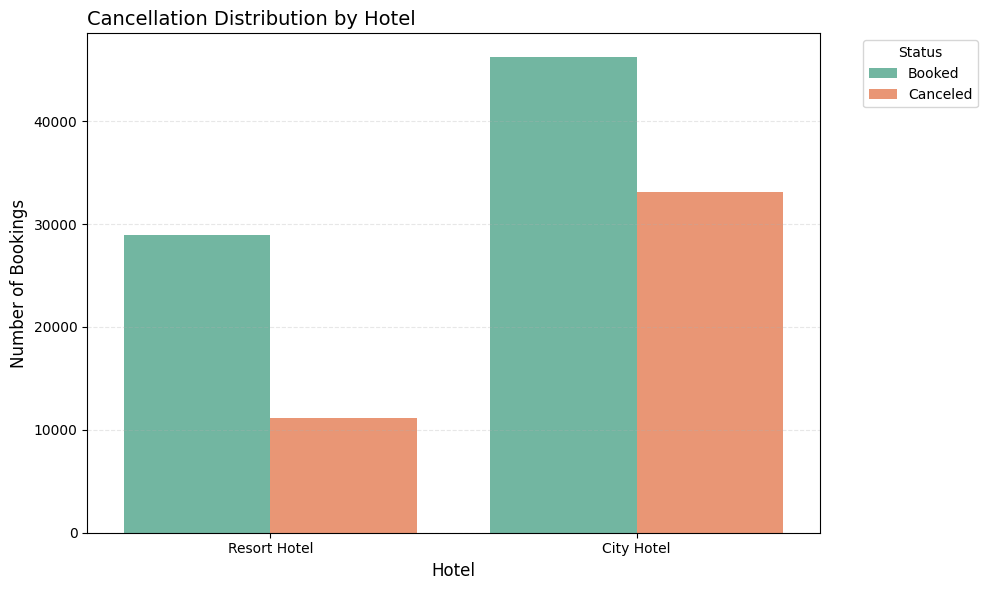

--Realtiv Cancellation Rate---
City Hotel: 41.73%
Resort Hotel: 27.76%


In [9]:
# Questions: Does the City Hotel or Resort Hotel has more cancellations? 
hotel_df = df.groupby('hotel')['is_canceled'].value_counts()

plt.figure(figsize=(10,6))
sns.countplot(data=df, x='hotel', hue='is_canceled', palette='Set2')
plt.title('Cancellation Distribution by Hotel', fontsize=14, loc='left')
plt.xlabel('Hotel', fontsize=12)
plt.ylabel('Number of Bookings', fontsize=12)
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left', title='Status', labels=['Booked', 'Canceled'])
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()


print('--Realtiv Cancellation Rate---')
city_hotel = round(33102 / (46228 + 33102) * 100, 2)
resort_hotel = round(11122 / (28938 + 11122) * 100, 2)
print(f'City Hotel: {city_hotel}%')
print(f'Resort Hotel: {resort_hotel}%')

### Analysis of Cancellation Distribution by Hotel
* **City Hotel:** The chart illustrates that the City Hotel experiences a significantly higher volume of cancellations in absolute numbers. When looking at the ratio, the cancellation rate reaches roughly **41.73%** (approx. 33,000 cancellations out of 79,000 total bookings). This is exceptionally high and requires a deep-dive evaluation into the underlying reasons.
* **Resort Hotel:** In contrast, the Resort Hotel shows a healthier balance between confirmed and canceled bookings. With a cancellation rate of about **27.76%** (approx. 11,000 cancellations out of 40,000 total bookings), it proves to be more stable, which is typical for leisure travel where trips are planned further in advance and less likely to be dropped.